# Task 2 — Step 4: CDAN — Class-Conditional Adversarial Alignment

Marginal alignment (DAN, DANN) can match $P(F(X))$ while mapping target examples of one class onto source examples of another. CDAN (Long et al., 2018) conditions the discriminator on the classifier's soft prediction through the multilinear map
$$g(x)=\operatorname{vec}\big(f\otimes p\big)\in\mathbb{R}^{512\cdot 7},\qquad f=F(x),\;p=\operatorname{softmax}(C(f))$$
so the discriminator must distinguish domains *within* predicted-class regions: $g$ places $f$ in the block of its predicted class, weighted by confidence.

**Identical to DANN except the discriminator input** (manual): same hidden width (256), ReLU, dropout 0.5, GRL schedule α(p), unit loss weight, and the same discriminator parameter group (10× lr), batch-scaled discriminator input and gradient clipping (see the DANN notebook). **No entropy conditioning, and neither $f$ nor $p$ is detached**, so the domain gradient also flows into the classifier head through $p$.

In [1]:
%matplotlib inline
import os, sys, json, math
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, ROOT)

import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from shared.src.seed import set_seed, SEED
from shared.src.pacs_data import PACSDataset, get_pacs_dataloaders, PACS_SOURCE_DOMAINS, PACS_CLASSES
from shared.src.pacs_protocol import freeze_bn_stats, MAX_EPOCHS, PATIENCE
from shared.src.losses import compute_mmd
from shared.src.plotting import use_style, SEQ_CMAP, DIV_CMAP, PALETTE, DOMAIN_COLORS, NEUTRAL, INK_2, color_of, save_show
from task2_domain_adaptation.src.backbone import ResNet18Backbone
from task2_domain_adaptation.src.discriminator import DomainDiscriminator
from task2_domain_adaptation.src.train import train_uda, grl_alpha, cdan_features
from task2_domain_adaptation.src.evaluate import evaluate_source_validation, evaluate_target

use_style()
set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA = os.path.join(ROOT, 'data', 'PACS')
SPLIT = os.path.join(ROOT, 'shared', 'splits', 'pacs_sketch_seed6304.json')
CKPT = os.path.join(ROOT, 'task2_domain_adaptation', 'checkpoints')
RES = os.path.join(ROOT, 'task2_domain_adaptation', 'results')
os.makedirs(CKPT, exist_ok=True); os.makedirs(RES, exist_ok=True)
print(f"device={device} | seed={SEED}")

device=cuda | seed=6304


## 1. Data
Each update: 8 labeled images from each source domain (24) + 24 **unlabeled** Sketch images. The target train loader yields `(image, label)` pairs because it wraps the same folder dataset, but the training loop discards the label (`x_t, _ = ...`).

In [2]:
src_train, src_val, tgt_train, tgt_eval = get_pacs_dataloaders(DATA, SPLIT, source_batch_size=8, target_batch_size=24, eval_batch_size=64)
print({d: len(l.dataset) for d, l in src_train.items()}, '| sketch (unlabeled):', len(tgt_train.dataset))
print('steps/epoch =', max(len(l) for l in src_train.values()), '(largest source domain; smaller loaders and the target loader are cycled)')

{'photo': 1336, 'art_painting': 1638, 'cartoon': 1875} | sketch (unlabeled): 3929
steps/epoch = 234 (largest source domain; smaller loaders and the target loader are cycled)


## 2. What the discriminator sees
For one batch at initialisation: the 7×512 multilinear map $f\otimes p$ of a single source image (left). The mass sits in the row of its predicted class. On the right, the average softmax confidence of source vs target images, which sets how much of each row is used.

g(x) shape: (24, 3584) = 7 classes x 512 features


C:\Users\moize\AppData\Local\Temp\ipykernel_16080\1398815603.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  a2.boxplot([F.softmax(ls, 1).max(1).values.cpu().numpy(), F.softmax(lt, 1).max(1).values.cpu().numpy()], labels=['source', 'target'])


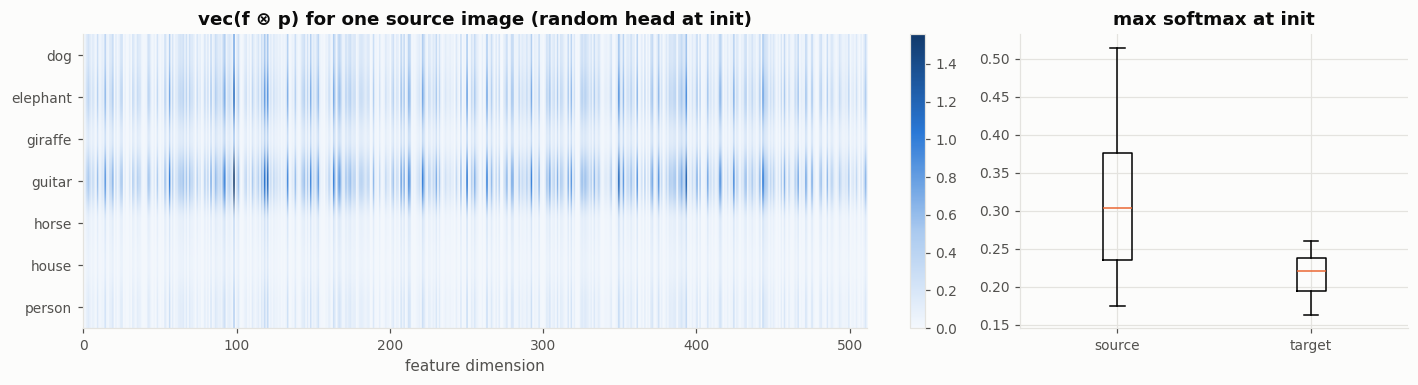

In [3]:
set_seed(SEED)
m0 = ResNet18Backbone(num_classes=7).to(device).eval()
with torch.no_grad():
    xs = torch.cat([next(iter(src_train[d]))[0] for d in PACS_SOURCE_DOMAINS]).to(device)
    xt = next(iter(tgt_train))[0].to(device)
    ls, fs = m0(xs); lt, ft = m0(xt)
    g = cdan_features(fs, ls)
print('g(x) shape:', tuple(g.shape), '= 7 classes x 512 features')
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 3.6), gridspec_kw={'width_ratios': [2.2, 1]})
im = a1.imshow(g[0].view(7, 512).cpu().numpy(), aspect='auto', cmap=SEQ_CMAP)
a1.set_yticks(range(7)); a1.set_yticklabels(PACS_CLASSES); a1.set_xlabel('feature dimension'); a1.grid(False)
a1.set_title('vec(f ⊗ p) for one source image (random head at init)'); fig.colorbar(im, ax=a1, fraction=0.03)
a2.boxplot([F.softmax(ls, 1).max(1).values.cpu().numpy(), F.softmax(lt, 1).max(1).values.cpu().numpy()], labels=['source', 'target'])
a2.set_title('max softmax at init'); fig.tight_layout(); save_show(fig, os.path.join(RES, 'cdan_multilinear_map.png'))

## 3. Train CDAN
Selection uses **only** mean source-validation macro-F1 (patience 5, ≤ 30 epochs (budget: `MAX_EPOCHS` / `PATIENCE` in `shared/src/pacs_protocol.py` = 30 / 5, as the manual specifies)). Set `FORCE_TRAIN = False` to reload.

In [4]:
FORCE_TRAIN = True
ckpt_path = os.path.join(CKPT, 'cdan.pth')
hist_path = os.path.join(CKPT, 'cdan_history.json')
CONFIG = dict(method='cdan', max_alpha=1.0, disc_lr_mult=10.0, grad_clip=1.0, disc_input='F(x) / detached batch-mean norm', lr=1e-4, wd=1e-4, max_epochs=MAX_EPOCHS, patience=PATIENCE, disc='3584-256-ReLU-Dropout0.5-2', seed=SEED)
TRAIN_KW = {'method', 'max_alpha', 'disc_lr_mult', 'grad_clip', 'lr', 'wd', 'max_epochs', 'patience'}

if FORCE_TRAIN or not os.path.exists(ckpt_path):
    set_seed(SEED)
    model = ResNet18Backbone(num_classes=7)
    discriminator = DomainDiscriminator(512 * 7, hidden_dim=256, dropout=0.5)
    out = train_uda(model, src_train, src_val, device, target_loader=tgt_train, discriminator=discriminator, save_path=ckpt_path, **{k: v for k, v in CONFIG.items() if k in TRAIN_KW})
    history, best_epoch, best_f1 = out['history'], out['best_epoch'], out['best_f1']
    json.dump({'config': CONFIG, 'history': history, 'best_epoch': best_epoch, 'best_f1': best_f1}, open(hist_path, 'w'), indent=1)
else:
    meta = json.load(open(hist_path)); history, best_epoch, best_f1 = meta['history'], meta['best_epoch'], meta['best_f1']
model = ResNet18Backbone(num_classes=7).to(device)
model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
print(f"selected epoch {best_epoch} | mean source-val macro-F1 {best_f1:.4f}")

[cdan] ep  1 | cls 0.511 | dom 0.578 acc 0.71 | alpha 0.17 | |f_s| 57.7 |f_t| 82.6 | tgt max-class 0.29 | val F1 0.8625 *
[cdan] ep  2 | cls 0.269 | dom 0.644 acc 0.65 | alpha 0.32 | |f_s| 70.2 |f_t| 56.5 | tgt max-class 0.27 | val F1 0.8447
[cdan] ep  3 | cls 0.329 | dom 0.693 acc 0.57 | alpha 0.46 | |f_s| 408.4 |f_t| 200.6 | tgt max-class 0.29 | val F1 0.8101
[cdan] ep  4 | cls 0.242 | dom 0.707 acc 0.56 | alpha 0.58 | |f_s| 134.7 |f_t| 237.7 | tgt max-class 0.24 | val F1 0.8936 *
[cdan] ep  5 | cls 0.179 | dom 0.699 acc 0.53 | alpha 0.68 | |f_s| 250.6 |f_t| 210.2 | tgt max-class 0.27 | val F1 0.9207 *
[cdan] ep  6 | cls 0.315 | dom 0.701 acc 0.48 | alpha 0.76 | |f_s| 497.8 |f_t| 894.7 | tgt max-class 0.36 | val F1 0.9243 *
[cdan] ep  7 | cls 0.196 | dom 0.697 acc 0.48 | alpha 0.82 | |f_s| 463.9 |f_t| 470.2 | tgt max-class 0.21 | val F1 0.8812
[cdan] ep  8 | cls 0.215 | dom 0.705 acc 0.50 | alpha 0.87 | |f_s| 696.4 |f_t| 1391.7 | tgt max-class 0.32 | val F1 0.8930
[cdan] ep  9 | cls 

## 4. Did CDAN train as intended? (label-free diagnostics)
Top row: classification loss, the alignment term, and the discriminator accuracy. Bottom row: source-validation macro-F1 per domain, mean feature norm for source vs target batches, and the share of target images assigned to each class. A healthy adaptation run keeps the classification loss low, keeps source-validation F1 stable, narrows the feature-norm gap, and **does not** push most target images into one class. None of these panels use Sketch labels.

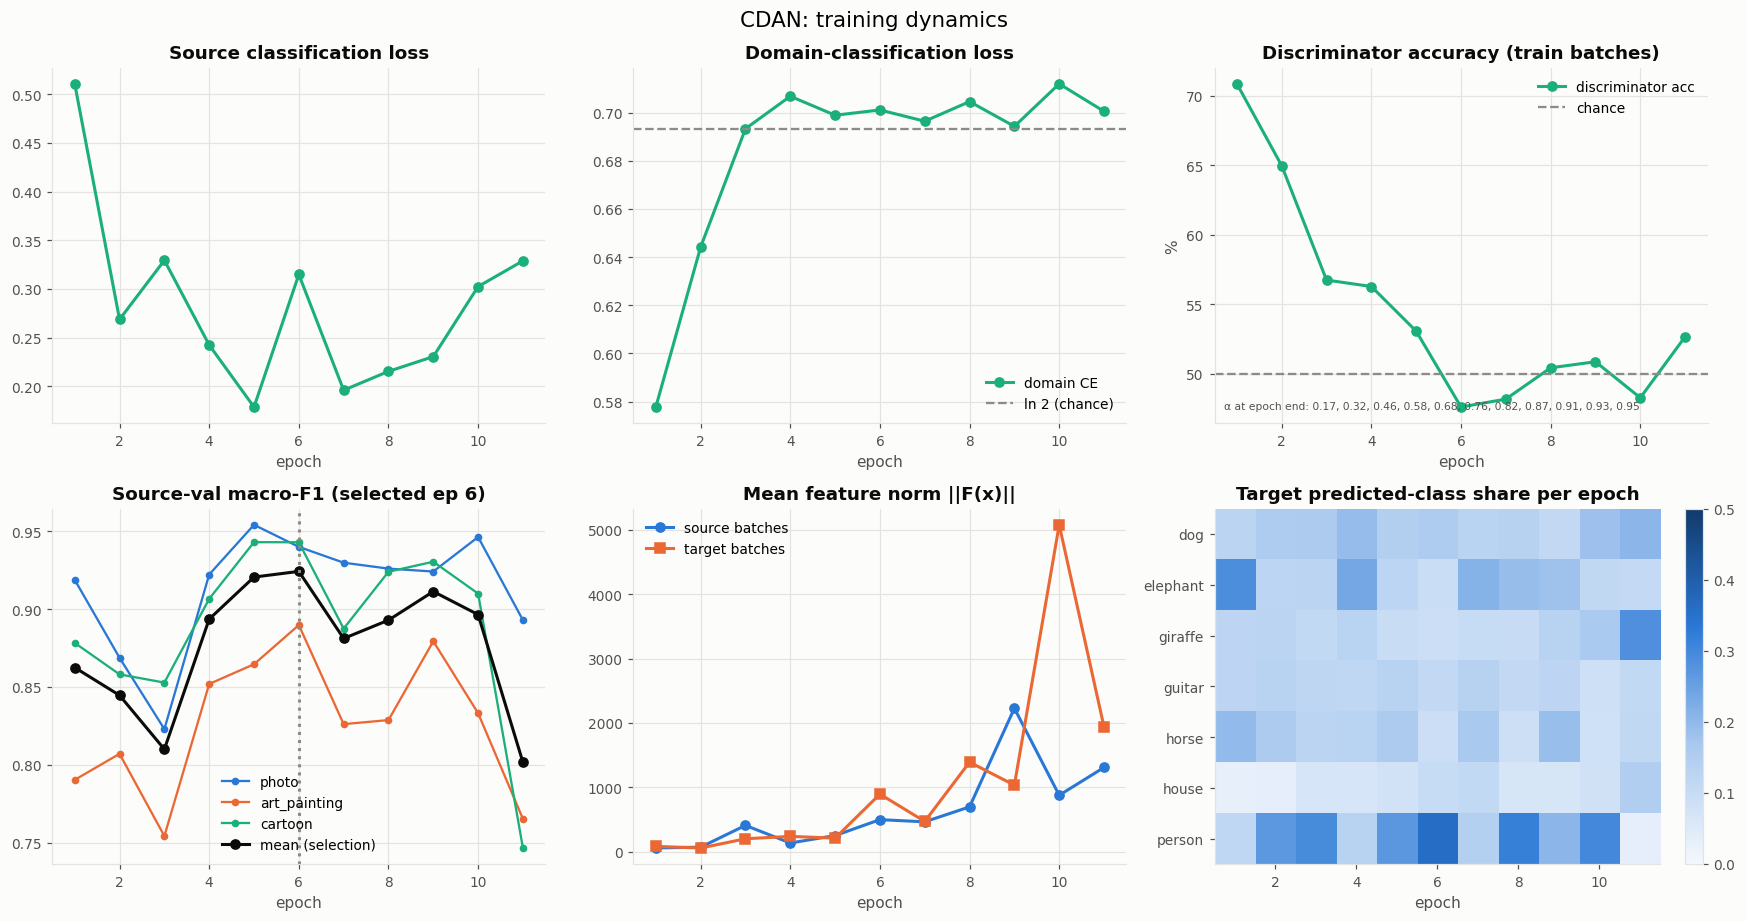

final-epoch target max-class share: 0.29 | at selected epoch: 0.36


In [5]:
H = history; ep = np.arange(1, len(H['cls_loss']) + 1)
fig, ax = plt.subplots(2, 3, figsize=(16, 8.5))
ax[0, 0].plot(ep, H['cls_loss'], 'o-', color=color_of('CDAN'))
ax[0, 0].set_title('Source classification loss'); ax[0, 0].set_xlabel('epoch')
ax[0, 1].plot(ep, H['align_loss'], 'o-', color=color_of('CDAN'), label='domain CE')
ax[0, 1].axhline(np.log(2), color=NEUTRAL, ls='--', lw=1.5, label='ln 2 (chance)'); ax[0, 1].set_title('Domain-classification loss'); ax[0, 1].legend(); ax[0, 1].set_xlabel('epoch')
ax[0, 2].plot(ep, 100 * np.array(H['dom_acc']), 'o-', color=color_of('CDAN'), label='discriminator acc')
ax[0, 2].axhline(50, color=NEUTRAL, ls='--', lw=1.5, label='chance')
ax[0, 2].set_title('Discriminator accuracy (train batches)'); ax[0, 2].set_ylabel('%'); ax[0, 2].legend(); ax[0, 2].set_xlabel('epoch')
ax[0, 2].text(0.02, 0.04, 'α at epoch end: ' + ', '.join(f'{a:.2f}' for a in H['alpha'][::max(1, len(ep)//6)]), transform=ax[0, 2].transAxes, fontsize=7, color=INK_2)
for d in PACS_SOURCE_DOMAINS:
    ax[1, 0].plot(ep, H['val_per_domain'][d]['f1'], 'o-', ms=4, lw=1.5, color=DOMAIN_COLORS[d], label=d)
ax[1, 0].plot(ep, H['val_mean_f1'], 'o-', color='#0b0b0b', label='mean (selection)')
ax[1, 0].axvline(best_epoch, color=NEUTRAL, ls=':'); ax[1, 0].set_title(f'Source-val macro-F1 (selected ep {best_epoch})'); ax[1, 0].legend(); ax[1, 0].set_xlabel('epoch')
ax[1, 1].plot(ep, H['src_feat_norm'], 'o-', color=DOMAIN_COLORS['source'], label='source batches')
ax[1, 1].plot(ep, H['tgt_feat_norm'], 's-', color=DOMAIN_COLORS['target'], label='target batches')
ax[1, 1].set_title('Mean feature norm ||F(x)||'); ax[1, 1].legend(); ax[1, 1].set_xlabel('epoch')
share = np.array(H['tgt_pred_hist']).T
im = ax[1, 2].imshow(share, aspect='auto', cmap=SEQ_CMAP, vmin=0, vmax=max(0.5, share.max()), extent=[0.5, len(ep) + 0.5, 6.5, -0.5])
ax[1, 2].set_yticks(range(7)); ax[1, 2].set_yticklabels(PACS_CLASSES); ax[1, 2].grid(False)
ax[1, 2].set_title('Target predicted-class share per epoch'); ax[1, 2].set_xlabel('epoch'); fig.colorbar(im, ax=ax[1, 2], fraction=0.046)
fig.suptitle('CDAN: training dynamics', fontsize=14); fig.tight_layout()
save_show(fig, os.path.join(RES, 'cdan_training_curves.png'))
print(f"final-epoch target max-class share: {H['tgt_max_class_share'][-1]:.2f} | at selected epoch: {H['tgt_max_class_share'][best_epoch-1]:.2f}")

## 5. Source-validation results (locked checkpoint)

In [6]:
src_metrics = evaluate_source_validation(model, src_val, device)
tab = pd.DataFrame({d: {'acc (%)': 100 * src_metrics[d]['acc'], 'macro-F1 (%)': 100 * src_metrics[d]['f1']} for d in PACS_SOURCE_DOMAINS}).T
tab.loc['mean'] = [100 * src_metrics['mean_acc'], 100 * src_metrics['mean_f1']]
tab.loc['worst'] = tab.loc[PACS_SOURCE_DOMAINS].min()
tab.round(2)

,acc (%),macro-F1 (%)
photo,94.91,94.01
art_painting,89.27,88.98
cartoon,93.82,94.30
mean,92.67,92.43
worst,89.27,88.98


## 6. Target (Sketch) evaluation
Configuration and checkpoint are fixed above; Sketch labels are used here only to measure the result.

In [7]:
tgt = evaluate_target(model, tgt_eval, device)
so = pd.read_csv(os.path.join(RES, 'source_only_summary.csv'), index_col=0).iloc[0]
delta = 100 * (tgt['acc'] - so['Target (Sketch) Acc'])
print(f"Sketch acc {100*tgt['acc']:.2f}% | macro-F1 {100*tgt['f1']:.2f}% | change vs Source-only {delta:+.2f} pp")
summary = pd.DataFrame([{
    'Photo Val Acc': src_metrics['photo']['acc'], 'Art Val Acc': src_metrics['art_painting']['acc'], 'Cartoon Val Acc': src_metrics['cartoon']['acc'],
    'Photo Val F1': src_metrics['photo']['f1'], 'Art Val F1': src_metrics['art_painting']['f1'], 'Cartoon Val F1': src_metrics['cartoon']['f1'],
    'Mean Source Val Acc': src_metrics['mean_acc'], 'Mean Source Val F1': src_metrics['mean_f1'],
    'Target (Sketch) Acc': tgt['acc'], 'Target (Sketch) F1': tgt['f1'], 'Delta Target Acc': delta / 100}], index=['CDAN'])
summary.to_csv(os.path.join(RES, 'cdan_summary.csv'))
summary.T.round(4)

Sketch acc 51.97% | macro-F1 46.99% | change vs Source-only -7.25 pp


,CDAN
Photo Val Acc,0.9491
Art Val Acc,0.8927
Cartoon Val Acc,0.9382
Photo Val F1,0.9401
Art Val F1,0.8898
Cartoon Val F1,0.9430
Mean Source Val Acc,0.9267
Mean Source Val F1,0.9243
Target (Sketch) Acc,0.5197
Target (Sketch) F1,0.4699


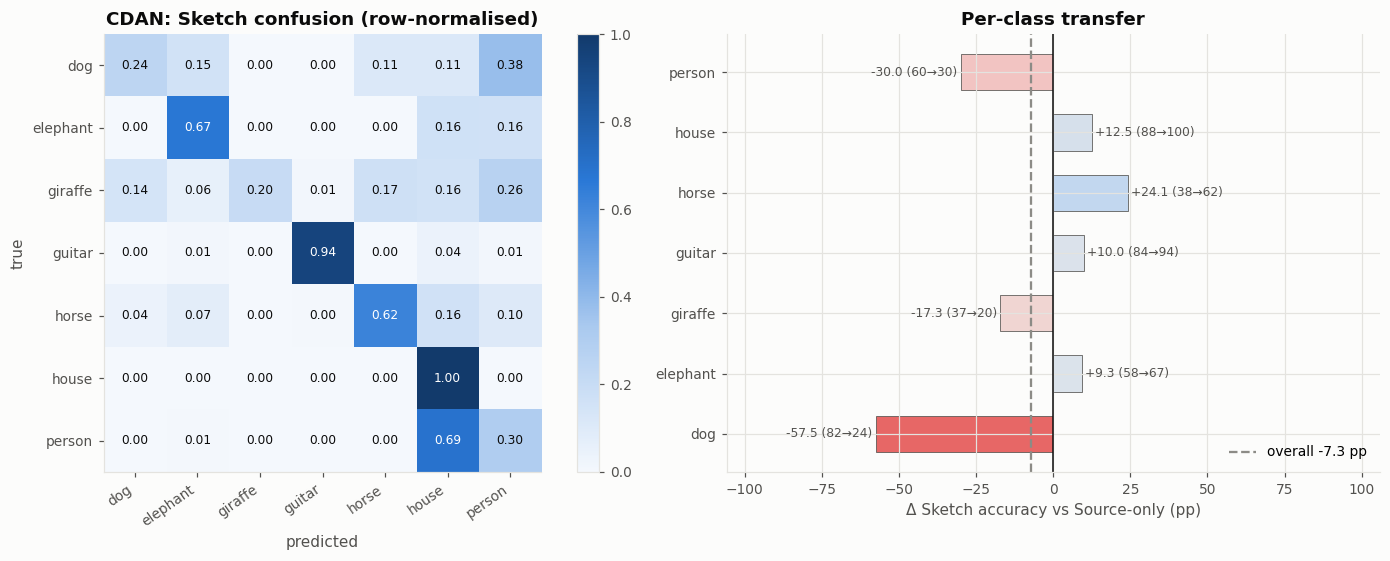

In [8]:
so_model = ResNet18Backbone(num_classes=7).to(device)
so_model.load_state_dict(torch.load(os.path.join(CKPT, 'source_only.pth'), map_location=device, weights_only=True))
so_tgt = evaluate_target(so_model, tgt_eval, device)
pc, pc_so = 100 * np.array(tgt['per_class_acc']), 100 * np.array(so_tgt['per_class_acc'])
dpc = pc - pc_so
cm = tgt['confusion_matrix']; cm_n = cm / cm.sum(1, keepdims=True)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={'width_ratios': [1.1, 1]})
im = a1.imshow(cm_n, cmap=SEQ_CMAP, vmin=0, vmax=1)
for i in range(7):
    for j in range(7):
        a1.text(j, i, f"{cm_n[i, j]:.2f}", ha='center', va='center', fontsize=8, color='white' if cm_n[i, j] > 0.55 else '#0b0b0b')
a1.set_xticks(range(7)); a1.set_xticklabels(PACS_CLASSES, rotation=35, ha='right'); a1.set_yticks(range(7)); a1.set_yticklabels(PACS_CLASSES)
a1.set_xlabel('predicted'); a1.set_ylabel('true'); a1.set_title('CDAN: Sketch confusion (row-normalised)'); a1.grid(False)
fig.colorbar(im, ax=a1, fraction=0.046)
lim = max(5, np.abs(dpc).max() * 1.15)
cols = [DIV_CMAP(0.5 + 0.5 * v / lim) for v in dpc]
bars = a2.barh(PACS_CLASSES, dpc, color=cols, height=0.6, edgecolor='#52514e', linewidth=0.5)
a2.axvline(0, color='#0b0b0b', lw=1); a2.axvline(delta, color=NEUTRAL, ls='--', lw=1.5, label=f'overall {delta:+.1f} pp')
for b, v, s, t in zip(bars, dpc, pc_so, pc):
    a2.text(v + (1 if v >= 0 else -1), b.get_y() + b.get_height() / 2, f"{v:+.1f} ({s:.0f}→{t:.0f})", va='center', ha='left' if v >= 0 else 'right', fontsize=8, color=INK_2)
a2.set_xlim(-lim * 1.6, lim * 1.6); a2.set_xlabel('Δ Sketch accuracy vs Source-only (pp)'); a2.set_title('Per-class transfer'); a2.legend(loc='lower right')
fig.tight_layout()
save_show(fig, os.path.join(RES, 'cdan_target_analysis.png'))